In [1]:
# Standard library
from pathlib import Path
import sys
import datetime

# Make the src package importable
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Third-party libraries
import pandas as pd
from sqlalchemy import text

# Local package
from src.database import get_engine

# Create database connection
engine = get_engine()

print("✅ Connected successfully!")

✅ Connected successfully!


In [3]:
print("Reading data from Silver Layer...")

df_sales = pd.read_sql("SELECT CustomerKey, OrderDate, SalesAmount FROM silver.FactInternetSales", con=engine)
df_customers = pd.read_sql("SELECT CustomerKey, FirstName, LastName, EmailAddress FROM silver.DimCustomer", con=engine)

# Convert OrderDate to datetime
df_sales['OrderDate'] = pd.to_datetime(df_sales["OrderDate"])

df_sales.head()


Reading data from Silver Layer...


,CustomerKey,OrderDate,SalesAmount
0,27645,2010-12-30,3578.27
1,16624,2010-12-30,3578.27
2,11005,2010-12-30,3374.99
3,11011,2010-12-30,3399.99
4,27621,2010-12-31,3578.27


In [4]:
print("Computing RFM and Customer Value metrics...")

# We use the day after the last recorded sale as our snapshot baseline
snapshot_date = df_sales['OrderDate'].max() + datetime.timedelta(days=1)

# Group by customer to aggregate metrics
rfm = df_sales.groupby('CustomerKey').agg(
    Recency=('OrderDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('SalesAmount', 'count'),
    MonetaryValue=('SalesAmount', 'sum')
).reset_index()

# Join Customer details with the calculated RFM metrics
gold_customer_mart = pd.merge(df_customers, rfm, on='CustomerKey', how='inner')

# Add Business Logic: Customer Segments
def segment_customer(row):
    if row['MonetaryValue'] >= 2000 and row['Frequency'] >= 3:
        return 'High Value Champions'
    elif row['Recency'] > 180 and row['MonetaryValue'] >= 1000:
        return 'At Risk (High Spenders)'
    else:
        return 'Standard'
    
gold_customer_mart['CustomerSegment'] = gold_customer_mart.apply(segment_customer,axis=1)

# Inspect your new Gold table before writing it to the database
gold_customer_mart.head()



Computing RFM and Customer Value metrics...


,CustomerKey,FirstName,LastName,EmailAddress,Recency,Frequency,MonetaryValue,CustomerSegment
0,11000,Jon,Yang,jon24@adventure-works.com,1,9,8283.98,High Value Champions
1,11001,Eugene,Huang,eugene10@adventure-works.com,357,11,6383.88,High Value Champions
2,11002,Ruben,Torres,ruben35@adventure-works.com,647,4,8114.04,High Value Champions
3,11003,Christy,Zhu,christy12@adventure-works.com,571,8,4739.30,High Value Champions
4,11004,Elizabeth,Johnson,elizabeth5@adventure-works.com,580,6,8196.01,High Value Champions


In [5]:
from sqlalchemy.types import Integer, NVARCHAR, DECIMAL

print("Writing processed data gold.FactCustomerMart...")

#Explicitly mapping Pandas columns to clean SQL Server data types
gold_dtypes = {
    'CustomerKey': Integer(),
    'FirstName': NVARCHAR(50),
    'LastName': NVARCHAR(50),
    'EmailAddress': NVARCHAR(50),
    'Recency': Integer(),
    'Frequency':Integer(),
    'MonetaryValue': DECIMAL(18,2),
    'CustomerSegment':NVARCHAR(50)
}

gold_customer_mart.to_sql(
    name='FactCustomerMart',
    con=engine,
    schema='gold',
    if_exists='replace', # Automatically handles dropping and recreating the table structure
    index=False,
    dtype=gold_dtypes
)

print("🎉 Gold Layer refresh complete with optimized schema!")

Writing processed data gold.FactCustomerMart...
🎉 Gold Layer refresh complete with optimized schema!


In [6]:
gold_customer_mart['CustomerSegment'].value_counts()

CustomerSegment
Standard                   10789
High Value Champions        4594
At Risk (High Spenders)     3100
Name: count, dtype: int64

In [7]:
gold_customer_mart.sort_values('MonetaryValue', ascending=False).head(5)

,CustomerKey,FirstName,LastName,EmailAddress,Recency,Frequency,MonetaryValue,CustomerSegment
1301,12301,Nichole,Nara,nichole16@adventure-works.com,377,13,13295.38,High Value Champions
1132,12132,Kaitlyn,Henderson,kaitlyn72@adventure-works.com,411,14,13294.27,High Value Champions
1309,12308,Margaret,He,margaret25@adventure-works.com,378,14,13269.27,High Value Champions
1131,12131,Randall,Dominguez,randall14@adventure-works.com,418,11,13265.99,High Value Champions
1300,12300,Adriana,Gonzalez,adriana19@adventure-works.com,411,10,13242.70,High Value Champions


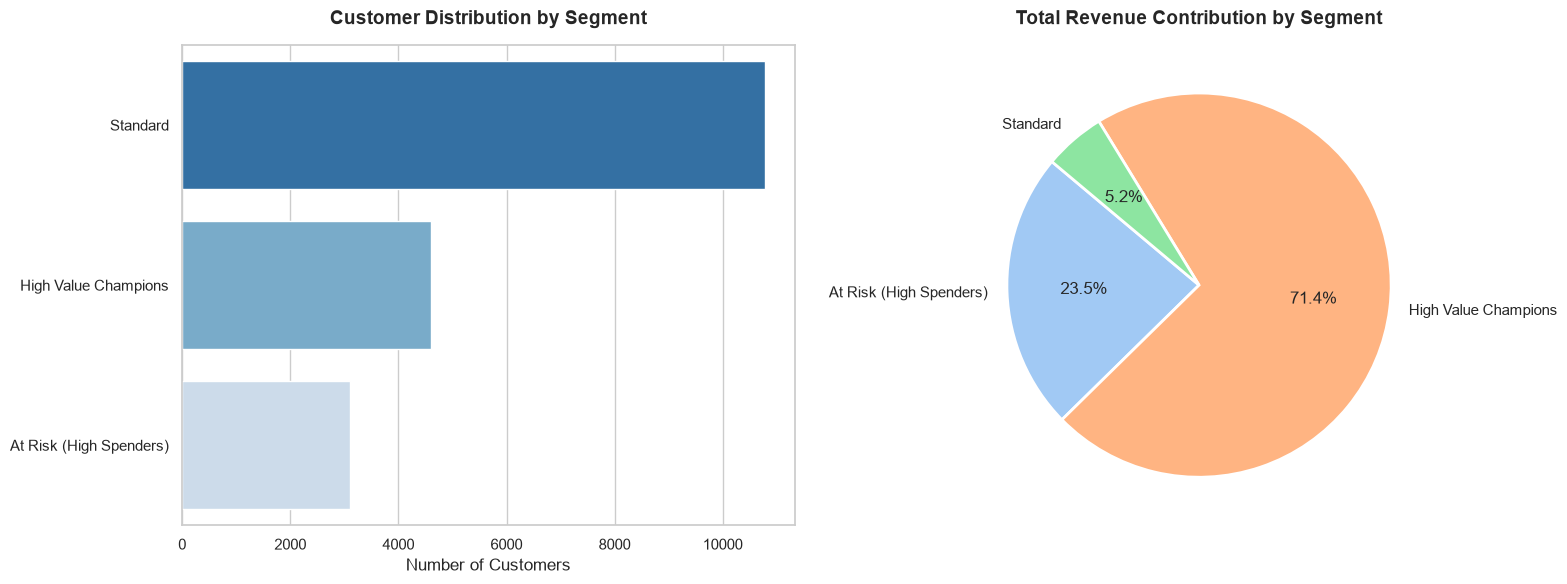

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [16,6]

fig, axes = plt.subplots(1,2)

# Chart 1: Customer Segmentation Count (Bar Chart) ---
segment_counts = gold_customer_mart['CustomerSegment'].value_counts().reset_index()

sns.barplot(
    data=segment_counts,
    x='count',
    y='CustomerSegment',
    ax=axes[0],
    palette='Blues_r',
    hue='CustomerSegment',
    legend=False
)
axes[0].set_title('Customer Distribution by Segment', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Customers', fontsize=12)
axes[0].set_ylabel('', fontsize=12)

# --- CHART 2: Revenue Generated by Segment (Pie Chart) ---
segment_revenue = gold_customer_mart.groupby('CustomerSegment')['MonetaryValue'].sum().reset_index()

axes[1].pie(
    segment_revenue['MonetaryValue'], 
    labels=segment_revenue['CustomerSegment'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')[0:3],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Total Revenue Contribution by Segment', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()